In [7]:
# --- Part 1: Data Preprocessing and Integration (Adapted for GSE240671) ---

import pandas as pd
import re
import warnings

# --- Suppress warnings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

def parse_series_matrix(file_path):
    """
    Parses a GEO series matrix file to extract sample IDs and clinical characteristics.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Get sample IDs (GSMs)
    sample_ids = []
    for line in lines:
        if line.startswith("!Sample_geo_accession"):
            sample_ids = line.strip().split('\t')[1:]
            sample_ids = [s.replace('"', '') for s in sample_ids]
            break

    # Obtain feature categories
    characteristics = {}
    for line in lines:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue

            first_value_cell = parts[1].replace('"', '')
            if ':' not in first_value_cell:
                continue

            # This logic automatically creates column names from the data
            feature_name_raw = first_value_cell.split(':')[0]
            feature_name = feature_name_raw.strip().replace(' ', '_').lower()

            prefix_to_remove = f"{feature_name_raw}: "
            values = [v.replace('"', '') for v in parts[1:]]
            cleaned_values = [v.replace(prefix_to_remove, "").strip() for v in values]

            characteristics[feature_name] = cleaned_values

    # Create a DataFrame for clinical data
    clinical_df = pd.DataFrame(characteristics)
    clinical_df.insert(0, 'sample_id', sample_ids)

    return clinical_df

def load_gene_id_map(annot_file_path):
    """
    Loads gene ID to symbol mapping from the local annotation TSV file.
    """
    print(f"Loading gene annotations from {annot_file_path}...")
    try:
        annot_df = pd.read_csv(
            annot_file_path, 
            sep='\t', 
            header=None, 
            usecols=[0, 1],
            on_bad_lines='skip', low_memory=False
        )
        annot_df.columns = ['gene_id', 'gene_symbol']
        annot_df.dropna(subset=['gene_id', 'gene_symbol'], inplace=True)
        id_to_symbol_map = dict(zip(annot_df['gene_id'].astype(str), annot_df['gene_symbol']))
        print(f"Successfully created mapping for {len(id_to_symbol_map)} genes.")
        return id_to_symbol_map

    except FileNotFoundError:
        print(f"Error: Annotation file not found at {annot_file_path}")
        return {}
    except Exception as e:
        print(f"Error reading annotation file: {e}")
        return {}

# --- Main Data Integration Workflow (GSE240671) ---

# 1. Parse clinical data from the new series matrix file
clinical_df = parse_series_matrix('GSE240671_series_matrix.txt') 

# 2. Load and transpose raw gene counts data
raw_counts_df = pd.read_csv('GSE240671_raw_counts_GRCh38.p13_NCBI.tsv', sep='\t', index_col=0) 
raw_counts_df = raw_counts_df.T
raw_counts_df.reset_index(inplace=True)
raw_counts_df.rename(columns={'index': 'sample_id'}, inplace=True)

# 3. Map gene IDs to gene symbols using the local annotation file
raw_counts_df.columns = raw_counts_df.columns.map(str)
gene_columns = raw_counts_df.columns[1:] 

gene_id_map = load_gene_id_map('Human.GRCh38.p13.annot.tsv') 

if gene_id_map:
    raw_counts_df = raw_counts_df.rename(columns=gene_id_map)
    print("Gene IDs successfully mapped to symbols.")
else:
    print("Warning: Gene ID mapping failed. Columns will remain as IDs.")

# 4. Merge clinical and expression data, then save to CSV
master_df = pd.merge(clinical_df, raw_counts_df, on='sample_id', how='inner')
master_df.set_index('sample_id', inplace=True)

master_df.to_csv('GSE240671_master_dataframe.csv')
print("\nMaster DataFrame created and saved to 'GSE240671_master_dataframe.csv'")

Loading gene annotations from Human.GRCh38.p13.annot.tsv...
Successfully created mapping for 39377 genes.
Gene IDs successfully mapped to symbols.

Master DataFrame created and saved to 'GSE240671_master_dataframe.csv'


--- Loading, Cleaning, and Splitting Data ---
Data split successful!
Train (80%) shape: (55, 39397)
Test (20%) shape: (14, 39397)
Identified 20 clinical columns to exclude from counts.
Using 55 samples with valid target labels for analysis.
--- Generating PCA Plot for All Genes (with Confidence Ellipses) ---
[saved] output\pca_all_genes.png


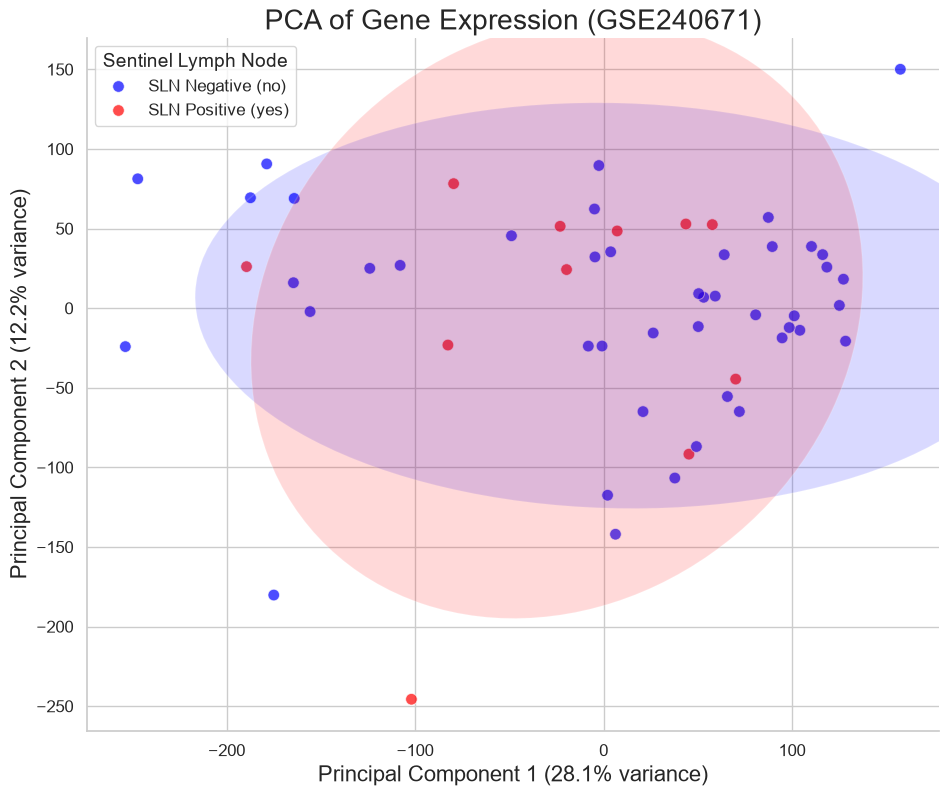

In [8]:
# --- Part 2: Exploratory Data Analysis (Adapted for GSE240671) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import warnings
from sklearn.model_selection import train_test_split

# --- Global Plotting Style Setup (Unchanged) ---
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.titlesize': 22,
})

# --- Suppress warnings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from pathlib import Path
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _savefig(filename: str, dpi: int = 300):
    """Save current matplotlib figure into output/ with tight layout."""
    fp = OUT_DIR / filename
    plt.savefig(fp, dpi=dpi, bbox_inches="tight")
    print(f"[saved] {fp}")
    
print("--- Loading, Cleaning, and Splitting Data ---")
# Load the master dataframe created in Part 1.
raw_master_df = pd.read_csv('GSE240671_master_dataframe.csv', index_col=0, low_memory=False)

target_col = 'sentinel_lymph_node'
target_map = {'no': 0, 'yes': 1}

raw_master_df_clean = raw_master_df.dropna(subset=[target_col]).copy()
y_temp = raw_master_df_clean[target_col].map(target_map)

# Perform an 80/20 split
df_train_80, df_test_20 = train_test_split(
    raw_master_df_clean, 
    test_size=0.20, 
    stratify=y_temp, 
    random_state=42
)

# Save the split datasets separately
df_train_80.to_csv('GSE240671_train_80.csv')
df_test_20.to_csv('GSE240671_test_20.csv')
print(f"Data split successful!")
print(f"Train (80%) shape: {df_train_80.shape}")
print(f"Test (20%) shape: {df_test_20.shape}")

master_df = df_train_80.copy()

# --- 1. Define Target Variable 'y' ---
### MODIFIED ###
target_col = 'sentinel_lymph_node'
target_map = {'no': 0, 'yes': 1}
y = master_df[target_col].map(target_map)

# --- 2. Define Clinical/Categorical Features ---
categorical_cols = [
    'tissue', 'timing_biopsies', 'sex', 'age_diagnostic', 'patient_id',
    'statut_menopausal', 'tum_size_max_diagnostic_(larger_diameter_in_mm)',
    'molecular_category', 'ki67_binary_(1_>_and_=_15%_et_0_<15%)',
    'rcb_category', 'unifocal', 'grade', 'node_invasion', 
    'nac_category', 'nac_herceptin_binary', 'breast_conservative_surgery',
    'radiotherapy_binary', 'hormonotherapy_type_category', 
    'sequencing_batch', 'mapped_to_intergenic_(%_reads)'
]

# --- 3. Separate Features (X) ---
# Drop the target column to create the feature matrix X
X = master_df.drop(columns=[target_col])

cat_cols_in_df = [col for col in categorical_cols if col in X.columns]
print(f"Identified {len(cat_cols_in_df)} clinical columns to exclude from counts.")

# --- 4. Isolate Gene Counts and Log-Transform ---
X_cont_raw = X.drop(columns=cat_cols_in_df, errors='ignore')
X_log_transformed = np.log1p(X_cont_raw)

# --- 5. Clean data for DESeq2 (remove samples with missing 'y') ---
valid_indices = y.dropna().index
y_clean = y.loc[valid_indices]
X_cont_raw_clean = X_cont_raw.loc[valid_indices]
X_log_transformed_clean = X_log_transformed.loc[valid_indices]

print(f"Using {len(y_clean)} samples with valid target labels for analysis.")

# --- 6. PCA on All Genes (Logic Unchanged) ---
print("--- Generating PCA Plot for All Genes (with Confidence Ellipses) ---")

# Scale the log-transformed data
scaler_global = StandardScaler()
X_log_scaled_global = scaler_global.fit_transform(X_log_transformed_clean)

# Perform PCA
pca_global = PCA(n_components=2)
principal_components_global = pca_global.fit_transform(X_log_scaled_global)

# Create a DataFrame for plotting
pca_df_global = pd.DataFrame(data=principal_components_global, columns=['PC1', 'PC2'], index=X_log_transformed_clean.index)

# 1. Define new plotting labels and palette
plot_labels = {0: 'SLN Negative (no)', 1: 'SLN Positive (yes)'}
palette = {'SLN Negative (no)': 'blue', 'SLN Positive (yes)': 'red'}

# 2. Map 'y_clean' to the new text labels for the legend
pca_df_global['Condition'] = y_clean.map(plot_labels).values
variance_explained_global = pca_global.explained_variance_ratio_

# --- Plotting Section with Ellipses ---
plt.figure(figsize=(11, 9))

# 3. Update 'hue' and 'palette'
ax = sns.scatterplot(
    x='PC1', y='PC2',
    hue='Condition', 
    data=pca_df_global,
    palette=palette, 
    s=70,
    alpha=0.7
)

# 4. Add 95% confidence ellipses (Logic Unchanged)
for category in pca_df_global['Condition'].unique(): 
    subset = pca_df_global[pca_df_global['Condition'] == category]

    if subset.shape[0] < 2:
        continue

    cov = np.cov(subset['PC1'], subset['PC2'])
    center = subset[['PC1', 'PC2']].mean().values

    if not (np.any(np.isnan(cov)) or np.any(np.isinf(cov))):
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
            width, height = 2 * 2 * np.sqrt(eigenvalues)

            ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                              facecolor=palette.get(category, 'gray'), alpha=0.15)
            ax.add_patch(ellipse)
        except np.linalg.LinAlgError:
            print(f"Could not compute confidence ellipse for '{category}' group.")

# 5. Update titles and labels
ax.set_title("PCA of Gene Expression (GSE240671)") # <-- MODIFIED
ax.set_xlabel(f'Principal Component 1 ({variance_explained_global[0] * 100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({variance_explained_global[1] * 100:.1f}% variance)')
ax.legend(title='Sentinel Lymph Node') # <-- MODIFIED
sns.despine()
_savefig("pca_all_genes.png")
plt.show()

In [9]:
# --- Part 3: DESeq2 Differential Expression Analysis ---

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("--- Running DESeq2 Differential Expression Analysis ---")

samples_df = pd.DataFrame({'condition': y_clean})

print(f"Running DESeq2 on {len(samples_df)} samples.")

dds = DeseqDataSet(
    counts=X_cont_raw_clean,
    metadata=samples_df,
    design='~condition'
)

dds.deseq2()

normalized_counts_df = pd.DataFrame(
    dds.layers['normed_counts'],
    index=X_cont_raw_clean.index,
    columns=X_cont_raw_clean.columns
)
normalized_counts_df.to_csv('GSE240671_deseq2_normalized_counts.csv')
print("DESeq2 normalized counts saved to 'GSE240671_deseq2_normalized_counts.csv'")

stat_res = DeseqStats(dds, contrast=['condition', 1, 0])

stat_res.summary()
results_df = stat_res.results_df
results_df.to_csv('GSE240671_deseq2_statistical_results.csv')
print("DESeq2 statistical results saved to 'GSE240671_deseq2_statistical_results.csv'")

padj_thresh = 0.05
log2fc_thresh = 1.0 

significant_genes_df = results_df[
    (results_df['padj'] < padj_thresh) &
    (abs(results_df['log2FoldChange']) > log2fc_thresh)
]

significant_genes = significant_genes_df.index.tolist()

print(f"\nDESeq2 analysis complete.")
print(f"Found {len(significant_genes)} significantly differentially expressed genes.")
print(f"(Using padj < {padj_thresh} and |log2FoldChange| > {log2fc_thresh})")

--- Running DESeq2 Differential Expression Analysis ---
Running DESeq2 on 55 samples.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 1.48 seconds.

Fitting dispersion trend curve...
... done in 0.43 seconds.

Fitting MAP dispersions...
... done in 1.78 seconds.

Fitting LFCs...
... done in 1.79 seconds.

Calculating cook's distance...
... done in 0.11 seconds.

Replacing 1130 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...
... done in 0.11 seconds.



DESeq2 normalized counts saved to 'GSE240671_deseq2_normalized_counts.csv'


Running Wald tests...
... done in 1.10 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
DDX11L1        16.321785       -0.154205  0.464935 -0.331670  0.740138   
WASH7P        183.817516        0.009194  0.189650  0.048481  0.961333   
MIR6859-1      10.517546       -0.208279  0.411930 -0.505618  0.613125   
MIR1302-2HG     4.337451       -0.608182  0.899210 -0.676352  0.498817   
MIR1302-2       0.920516       -1.427502  1.305084 -1.093801  0.274042   
...                  ...             ...       ...       ...       ...   
ND6          1655.447856        0.477844  0.254098  1.880546  0.060034   
TRNE           95.168338        0.260368  0.376576  0.691410  0.489308   
CYTB         3272.479558        0.436618  0.262857  1.661050  0.096703   
TRNT           52.788807        0.216750  0.417221  0.519510  0.603405   
TRNP           77.773319        0.145428  0.452175  0.321618  0.747742   

                 padj  
DDX11L1           NaN  
WASH7P  

--- Visualizing results for 59 significant genes ---

--- Generating PCA Plot for Significant Genes ---
[saved] output\pca_significant_genes.png


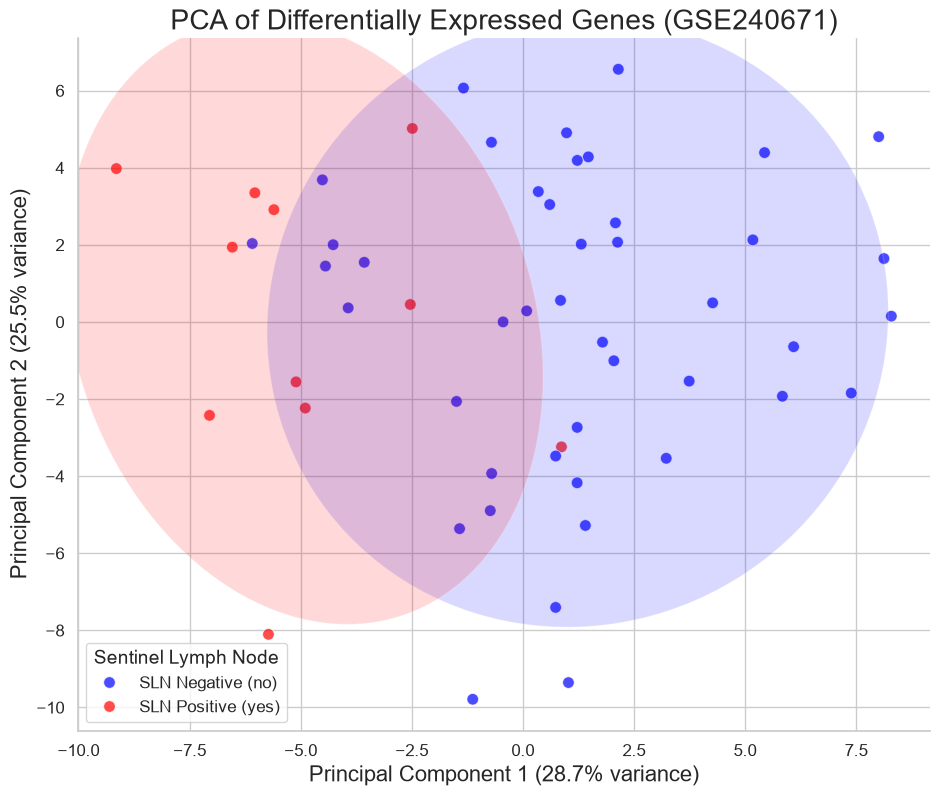

In [10]:
# --- Part 4: Visualization of Significant Genes ---
print(f"--- Visualizing results for {len(significant_genes)} significant genes ---")

# --- 1. PCA on Differentially Expressed Genes (DEGs) ---
print("\n--- Generating PCA Plot for Significant Genes ---")

X_significant_log = X_log_transformed_clean[significant_genes]

scaler_sig = StandardScaler()
X_significant_scaled = scaler_sig.fit_transform(X_significant_log)

pca_sig = PCA(n_components=2)
principal_components_sig = pca_sig.fit_transform(X_significant_scaled)

pca_df_sig = pd.DataFrame(data=principal_components_sig, columns=['PC1', 'PC2'], index=X_significant_log.index)

pca_df_sig['Condition'] = y_clean.map(plot_labels).values
variance_explained_sig = pca_sig.explained_variance_ratio_

plt.figure(figsize=(11, 9))
ax_pca_sig = sns.scatterplot(
    x='PC1', y='PC2', hue='Condition', data=pca_df_sig,
    palette=palette, s=70, alpha=0.7
)

for category in pca_df_sig['Condition'].unique():
    subset = pca_df_sig[pca_df_sig['Condition'] == category]
    if subset.shape[0] > 1:
        cov = np.cov(subset['PC1'], subset['PC2'])
        center = subset[['PC1', 'PC2']].mean().values
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
            width, height = 2 * 2 * np.sqrt(eigenvalues)
            ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                              facecolor=palette.get(category, 'gray'), alpha=0.15)
            ax_pca_sig.add_patch(ellipse)
        except np.linalg.LinAlgError:
            pass 

ax_pca_sig.set_title("PCA of Differentially Expressed Genes (GSE240671)")
ax_pca_sig.set_xlabel(f'Principal Component 1 ({variance_explained_sig[0] * 100:.1f}% variance)')
ax_pca_sig.set_ylabel(f'Principal Component 2 ({variance_explained_sig[1] * 100:.1f}% variance)')
ax_pca_sig.legend(title='Sentinel Lymph Node')
sns.despine()
_savefig("pca_significant_genes.png")
plt.show()


--- Generating Centered Volcano Plot ---
[saved] output\volcano_plot.png


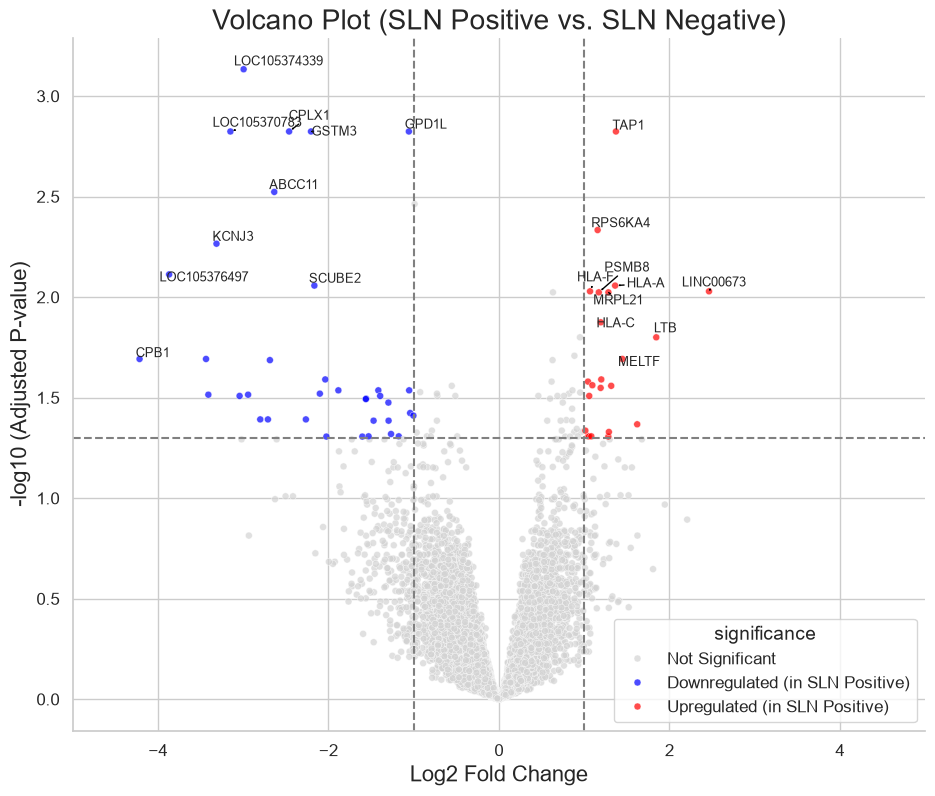

In [11]:
# --- 2. Volcano Plot ---
from adjustText import adjust_text

print("\n--- Generating Centered Volcano Plot ---")

results_df['-log10(padj)'] = -np.log10(results_df['padj'])
results_df.replace([np.inf, -np.inf], np.nan, inplace=True)
results_df.dropna(subset=['-log10(padj)'], inplace=True)

results_df['significance'] = 'Not Significant'
results_df.loc[(results_df['padj'] < padj_thresh) & (
            results_df['log2FoldChange'] > log2fc_thresh), 'significance'] = 'Upregulated (in SLN Positive)'
results_df.loc[(results_df['padj'] < padj_thresh) & (
            results_df['log2FoldChange'] < -log2fc_thresh), 'significance'] = 'Downregulated (in SLN Positive)'

top_upregulated = results_df[results_df['significance'].str.startswith('Upregulated')].sort_values('padj').head(10)
top_downregulated = results_df[results_df['significance'].str.startswith('Downregulated')].sort_values('padj').head(10)
genes_to_annotate = pd.concat([top_upregulated, top_downregulated])

plt.figure(figsize=(11, 9))
volcano_palette = {
    'Upregulated (in SLN Positive)': 'red', 
    'Downregulated (in SLN Positive)': 'blue', 
    'Not Significant': 'lightgrey'
}
ax_volcano = sns.scatterplot(
    data=results_df, x='log2FoldChange', y='-log10(padj)',
    hue='significance', palette=volcano_palette,
    s=25, alpha=0.7, legend='full'
)

ax_volcano.axvline(x=log2fc_thresh, color='grey', linestyle='--')
ax_volcano.axvline(x=-log2fc_thresh, color='grey', linestyle='--')
ax_volcano.axhline(y=-np.log10(padj_thresh), color='grey', linestyle='--')

texts = []
for idx, row in genes_to_annotate.iterrows():
    texts.append(plt.text(row['log2FoldChange'], row['-log10(padj)'], idx, fontsize=9))

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

limit = max(np.ceil(results_df['log2FoldChange'].abs().max()), log2fc_thresh + 0.5)
ax_volcano.set_xlim(-limit, limit)

ax_volcano.set_title('Volcano Plot (SLN Positive vs. SLN Negative)')
ax_volcano.set_xlabel('Log2 Fold Change')
ax_volcano.set_ylabel('-log10 (Adjusted P-value)')
sns.despine()
_savefig("volcano_plot.png")
plt.show()


--- Generating Clustered Heatmap ---


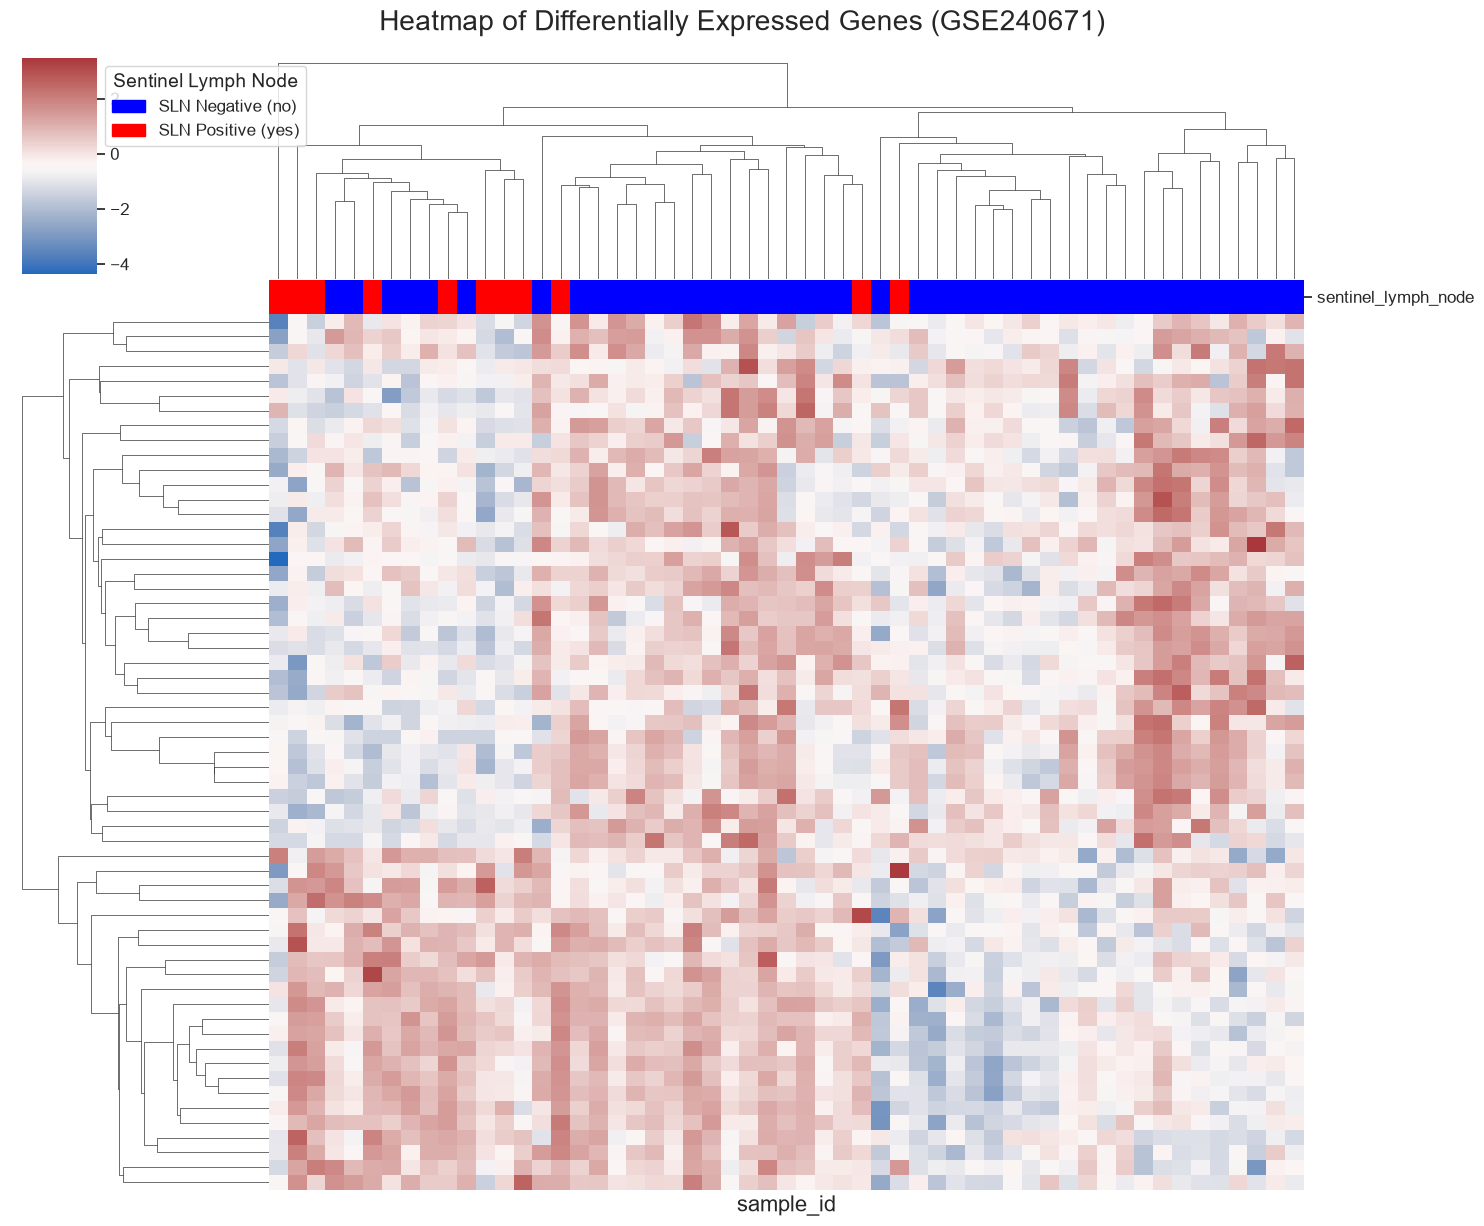

In [12]:
# --- 3. Clustered Heatmap ---
from scipy.stats import zscore

print("\n--- Generating Clustered Heatmap ---")

heatmap_data = X_log_transformed_clean[significant_genes]

heatmap_data_zscored = heatmap_data.apply(zscore, axis=0)
heatmap_data_zscored.fillna(0, inplace=True)

condition_categories = y_clean.map(plot_labels)
col_colors = condition_categories.map(palette)


g = sns.clustermap(
    heatmap_data_zscored.T,  
    cmap='vlag', 
    col_colors=col_colors,
    figsize=(15, 12),
    yticklabels=False, 
    xticklabels=False 
)

g.fig.suptitle('Heatmap of Differentially Expressed Genes (GSE240671)', fontsize=20, y=1.02)
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in palette.values()]
plt.legend(handles, palette.keys(), title='Sentinel Lymph Node', bbox_to_anchor=(1, 1), loc='upper left')
g.fig.savefig(OUT_DIR / "heatmap_deg_clustermap.png", dpi=300, bbox_inches="tight")
plt.show()